In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso, lasso_path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Load the cleaned dataset (same source as Phase 3)
df = pd.read_csv("merged_data.csv")
print(f"Loaded: {df.shape[0]:,} rows and {df.shape[1]} cols")
df.head()

Loaded: 51,189 rows and 18 cols


,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


In [3]:
# Column definitions

numeric_cols = [
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "person_capacity", 
    "bedrooms", 
    "dist", 
    "metro_dist",
    "attr_index", 
    "rest_index"]

binary_cols = [
    "room_type_apt", 
    "room_type_private",
    "is_superhost", 
    "multi", 
    "biz", 
    "is_weekday"]

categorical_cols = ["city"]

target_col = "logSum"

raw_feature_cols = numeric_cols + binary_cols + categorical_cols

X = df[raw_feature_cols].copy()
y = df[target_col].copy()

# Train/ Test Split (80/20 and stratified by city)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=df["city"])

print(f"Train: {X_train_raw.shape[0]:,} rows\n")
print(f"Test: {X_test_raw.shape[0]:,} rows\n")
print(f"City Distribution in Training Set:\n\n{X_train_raw['city'].value_counts().sort_index().to_string()}")

Train: 40,951 rows

Test: 10,238 rows

City Distribution in Training Set:

city
Amsterdam    1555
Athens       4223
Barcelona    2250
Berlin       1976
Budapest     3213
Lisbon       4608
London       7834
Paris        5257
Rome         7208
Vienna       2827


In [4]:
# Preprocessing Transformer (fit on training data only, no cross-validation or hyperparameter tuning here)
# Produces X_train_scaled / X_test_scaled 
# Used by statsmodels OLS and the coefficient-table / path-plot cells that require named DataFrame columns.

# Steps:
# scale_numeric: StandardScaler on the numeric predictors
# binary: passthrough (already 0/1)
# city_dummies: OneHotEncoder(drop='first') on city

preprocess = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), numeric_cols),

        ("binary", "passthrough", binary_cols),

        ("city_dummies", OneHotEncoder(
            drop="first", 
            handle_unknown="ignore", 
            sparse_output=False
            ), categorical_cols),
    ],
    remainder="drop",
)

preprocess.fit(X_train_raw)

city_dummy_cols = list(
    preprocess.named_transformers_["city_dummies"].get_feature_names_out(categorical_cols)
)
feature_cols = numeric_cols + binary_cols + city_dummy_cols

X_train_processed = pd.DataFrame(
    preprocess.transform(X_train_raw), columns=feature_cols, index=X_train_raw.index,
)

X_test_processed = pd.DataFrame(
    preprocess.transform(X_test_raw),  columns=feature_cols, index=X_test_raw.index,
)

In [5]:
# --- Fit full City FE OLS on training set (baseline for stepwise comparison) ---
model_city_fe = sm.OLS(y_train, sm.add_constant(X_train_processed)).fit()

train_preds_fe = model_city_fe.predict(sm.add_constant(X_train_processed))
test_preds_fe  = model_city_fe.predict(sm.add_constant(X_test_processed))
train_rmse_fe  = np.sqrt(np.mean((y_train - train_preds_fe) ** 2))
test_rmse_fe   = np.sqrt(np.mean((y_test  - test_preds_fe)  ** 2))

print(f"City FE predictor set: {len(X_train_processed.columns)} features")
print(f"\nModel Performance on full training set:")
print(f"AIC = {model_city_fe.aic:.2f}")
print(f"BIC = {model_city_fe.bic:.2f}")
print(f"R² = {model_city_fe.rsquared:.4f}")
print(f"Train RMSE = {train_rmse_fe:.4f}")
print(f"Test RMSE = {test_rmse_fe:.4f}")


City FE predictor set: 23 features

Model Performance on full training set:
AIC = 23549.12
BIC = 23756.01
R² = 0.6682
Train RMSE = 0.3224
Test RMSE = 0.3265


In [6]:
print(model_city_fe.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          5.5428      0.021    265.225      0.000       5.502       5.584
cleanliness_rating             0.0369      0.002     16.061      0.000       0.032       0.041
guest_satisfaction_overall     0.0066      0.002      2.828      0.005       0.002       0.011
person_capacity                0.1150      0.002     50.352      0.000       0.110       0.119
bedrooms                       0.0759      0.002     38.123      0.000       0.072       0.080
dist                          -0.0547      0.003    -19.604      0.000      -0.060      -0.049
metro_dist                    -0.0163      0.002     -7.830      0.000      -0.020      -0.012
attr_index                     0.0794      0.003     25.084      0.000       0.073       0.086
rest_index                     0.0555      0.004  

In [7]:
# --- Stepwise Selection Helper Functions ---

def backward_stepwise(X_train, y_train, criterion="aic"):
    """
    Backward stepwise selection by AIC (or BIC).
    Starts with all features; drops one at a time while criterion improves.
    """
    features = list(X_train.columns)
    current_model = sm.OLS(y_train, sm.add_constant(X_train[features])).fit()
    current_score = getattr(current_model, criterion)
    steps = []
    print(f"[Backward] \nStart: {len(features)} features, {criterion.upper()} = {current_score:.2f}")

    while len(features) > 1:
        candidates = {}
        for col in features:
            remaining = [f for f in features if f != col]
            m = sm.OLS(y_train, sm.add_constant(X_train[remaining])).fit()
            candidates[col] = getattr(m, criterion)

        best_drop = min(candidates, key=candidates.get)
        if candidates[best_drop] < current_score:
            current_score = candidates[best_drop]
            features.remove(best_drop)
            steps.append(("drop", best_drop, current_score, len(features)))
            print(f"Drop '{best_drop:<20s}' -> {criterion.upper()} = {current_score:.2f}  ({len(features)} remaining)")
        else:
            print(f"No improvement — stopping at {len(features)} features.")
            break

    final = sm.OLS(y_train, sm.add_constant(X_train[features])).fit()
    return features, final, steps


def forward_stepwise(X_train, y_train, candidates, criterion="aic"):
    """
    Forward stepwise selection by AIC (or BIC).
    Starts from intercept only; adds one feature at a time while criterion improves.
    """
    selected = []
    remaining = list(candidates)
    # Intercept-only baseline
    current_model = sm.OLS(y_train, np.ones(len(y_train))).fit()
    current_score = getattr(current_model, criterion)
    steps = []
    print(f"[Forward] \nStart: intercept only, {criterion.upper()} = {current_score:.2f}")

    while remaining:
        scores = {}
        for col in remaining:
            trial = selected + [col]
            m = sm.OLS(y_train, sm.add_constant(X_train[trial])).fit()
            scores[col] = getattr(m, criterion)

        best_add = min(scores, key=scores.get)
        if scores[best_add] < current_score:
            current_score = scores[best_add]
            selected.append(best_add)
            remaining.remove(best_add)
            steps.append(("add", best_add, current_score, len(selected)))
            print(f"Add  '{best_add:<20s}' -> {criterion.upper()} = {current_score:.2f}  ({len(selected)} selected)")
        else:
            print(f"No improvement — stopping at {len(selected)} features.")
            break

    final = sm.OLS(y_train, sm.add_constant(X_train[selected])).fit()
    return selected, final, steps

In [8]:
# --- Run Backward Stepwise ---
print("=" * 65)
back_features, model_back, back_steps = backward_stepwise(X_train_processed, y_train, criterion="aic")


[Backward] 
Start: 23 features, AIC = 23549.12
No improvement — stopping at 23 features.


In [9]:
# print(f"\nBackward selected {len(back_features)} features:")
# for feat in back_features:
#     print(f"{feat}")

In [10]:
# --- Run Forward Stepwise ---
print("=" * 65)
fwd_features, model_fwd, fwd_steps = forward_stepwise(X_train_processed, y_train, candidates=X_train_processed.columns, criterion="aic")


[Forward] 
Start: intercept only, AIC = 68683.02
Add  'room_type_apt       ' -> AIC = 63871.44  (1 selected)
Add  'city_Athens         ' -> AIC = 56444.88  (2 selected)
Add  'city_Budapest       ' -> AIC = 51620.23  (3 selected)
Add  'city_Rome           ' -> AIC = 47210.36  (4 selected)
Add  'attr_index          ' -> AIC = 40755.23  (5 selected)
Add  'person_capacity     ' -> AIC = 36584.51  (6 selected)
Add  'city_Lisbon         ' -> AIC = 34226.51  (7 selected)
Add  'city_Vienna         ' -> AIC = 31942.76  (8 selected)
Add  'bedrooms            ' -> AIC = 30650.16  (9 selected)
Add  'dist                ' -> AIC = 29290.59  (10 selected)
Add  'city_Barcelona      ' -> AIC = 28370.83  (11 selected)
Add  'cleanliness_rating  ' -> AIC = 27786.90  (12 selected)
Add  'biz                 ' -> AIC = 27310.70  (13 selected)
Add  'room_type_private   ' -> AIC = 26842.11  (14 selected)
Add  'city_Berlin         ' -> AIC = 26428.23  (15 selected)
Add  'city_Paris          ' -> AIC = 26033.53

In [11]:
# print(f"\nForward selected {len(fwd_features)} features:\n")
# for feat in fwd_features:
#     print(f"{feat}")

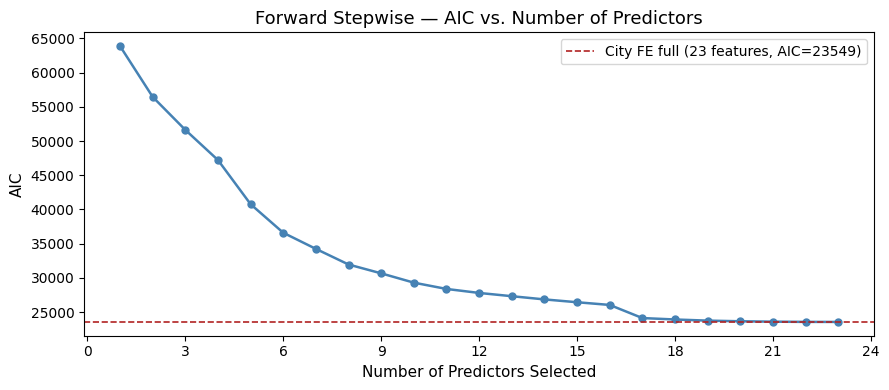

In [12]:
# --- AIC Progression Plot (Forward Stepwise) ---
if fwd_steps:
    steps_n   = [s[3] for s in fwd_steps]
    steps_aic = [s[2] for s in fwd_steps]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(steps_n, steps_aic, marker="o", color="steelblue", linewidth=1.8, markersize=5)
    ax.axhline(
        model_city_fe.aic, 
        color="firebrick", 
        linestyle="--", 
        linewidth=1.2,
        label=f"City FE full ({len(X_train_processed.columns)} features, AIC={model_city_fe.aic:.0f})"
        )
    ax.set_xlabel("Number of Predictors Selected", fontsize=11)
    ax.set_ylabel("AIC", fontsize=11)
    ax.set_title("Forward Stepwise — AIC vs. Number of Predictors", fontsize=13)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("plots/section4_PlotSelection1_stepwiseAIC.png", dpi=300, bbox_inches="tight")
    plt.show()

In [13]:
# CV Pipeline
# Returns (X_cv, sklearn_Pipeline) ready for cross_val_score and GridSearchCV
# All preprocessing is re-fit inside each fold; no leakage
# use_city = True: OneHotEncoder(drop='first') on city column
# use_city = False: no city encoding (models without city fixed effects)

def _make_cv_pipe(estimator, use_city):
    transformers = []

    transformers += [
        ("scale_numeric", StandardScaler(), numeric_cols),
        ("binary",        "passthrough",    binary_cols),
    ]

    if use_city:
        transformers.append((
            "city_dummies",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ))

    raw_cols = numeric_cols + binary_cols + (categorical_cols if use_city else [])
    
    X_cv = X_train_raw[raw_cols].copy()
    
    pipe = Pipeline([
        ("prep",  ColumnTransformer(transformers, remainder="drop")),
        ("model", estimator),
    ])

    return X_cv, pipe

In [14]:
# --- Phase 4 Part 3: Ridge Regression ---
# Tune regularization strength λ (sklearn: alpha) via 10-fold CV.
# Same 23-predictor City FE feature set; standardized data from Part 1.
# Cross-validation is leakage-safe: scaling are re-fit
# inside each fold of the Pipeline.

# λ grid: 0.001 → 10,000
alphas = np.logspace(-3, 4, 500)

X_ridge_cv, ridge_pipe = _make_cv_pipe(Ridge(), use_city=True)

ridge_cv = GridSearchCV(
    ridge_pipe,
    param_grid={"model__alpha": alphas},
    cv=10,
    scoring="neg_mean_squared_error",
)

ridge_cv.fit(X_ridge_cv, y_train)

best_alpha = ridge_cv.best_params_["model__alpha"]
cv_rmse_ridge = np.sqrt(-ridge_cv.best_score_)
print(f"Optimal λ  : {best_alpha:.4f}")
print(f"CV-RMSE    : {cv_rmse_ridge:.4f}")

# Refit with optimal λ to get a plain Ridge object for the downstream
# coefficient-table and path-plot cells that index into coef_ by name.
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_processed, y_train)

train_pred_ridge = ridge_best.predict(X_train_processed)
test_pred_ridge  = ridge_best.predict(X_test_processed)
train_rmse_ridge = np.sqrt(np.mean((y_train - train_pred_ridge) ** 2))
test_rmse_ridge  = np.sqrt(np.mean((y_test  - test_pred_ridge)  ** 2))

print(f"Train RMSE : {train_rmse_ridge:.4f}")
print(f"Test RMSE  : {test_rmse_ridge:.4f}")


Optimal λ  : 0.0030
CV-RMSE    : 0.3226
Train RMSE : 0.3224
Test RMSE  : 0.3265


In [15]:
# Coefficient comparison: OLS vs Ridge
ols_coefs = model_city_fe.params.drop("const")
coef_comparison = pd.DataFrame({
    "Full OLS":   ols_coefs.values,
    "Full Ridge": ridge_best.coef_,
}, index=X_train_processed.columns)
coef_comparison["L2 Shrinkage"] = ((coef_comparison["Full OLS"] - coef_comparison["Full Ridge"]).abs()).round(6)
coef_comparison

,Full OLS,Full Ridge,L2 Shrinkage
cleanliness_rating,0.036913,0.036913,0.000000
guest_satisfaction_overall,0.006627,0.006627,0.000000
person_capacity,0.114951,0.114950,0.000000
bedrooms,0.075935,0.075935,0.000000
dist,-0.054671,-0.054671,0.000001
metro_dist,-0.016253,-0.016253,0.000001
attr_index,0.079369,0.079370,0.000001
rest_index,0.055498,0.055497,0.000001
room_type_apt,0.826413,0.826399,0.000013
room_type_private,0.408385,0.408372,0.000013


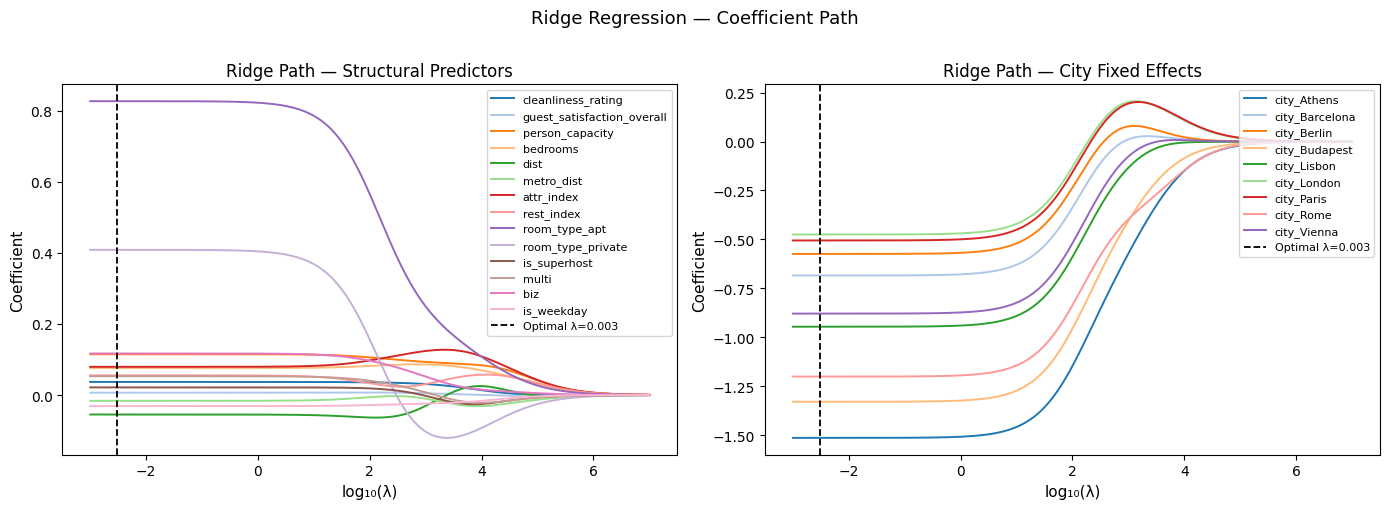

In [16]:
# --- Ridge Coefficient Path ---
alphas_path = np.logspace(-3, 7, 300)
coefs_path  = np.array([
    Ridge(alpha=a).fit(X_train_processed, y_train).coef_
    for a in alphas_path
])   # shape: (300, 23)

# Separate city dummies from structural predictors for visual clarity
structural = [c for c in X_train_processed.columns if not c.startswith("city_")]
city_cols   = [c for c in X_train_processed.columns if c.startswith("city_")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, group, title in zip(
    axes,
    [structural, city_cols],
    ["Structural Predictors", "City Fixed Effects"],
):
    idxs = [X_train_processed.columns.get_loc(c) for c in group]
    colors = [plt.cm.tab20(i) for i in range(len(group))]
    for (j, col), color in zip(zip(idxs, group), colors):
        ax.plot(np.log10(alphas_path), coefs_path[:, j], linewidth=1.4, label=col, color=color)
    ax.axvline(np.log10(best_alpha), color="black", linestyle="--", linewidth=1.3, label=f"Optimal λ={best_alpha:.3f}")
    ax.set_xlabel("log₁₀(λ)", fontsize=11)
    ax.set_ylabel("Coefficient", fontsize=11)
    ax.set_title(f"Ridge Path — {title}", fontsize=12)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Ridge Regression — Coefficient Path", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/section4_PlotRegularization1_ridgeCoefficientPath.png", dpi=300, bbox_inches="tight")
plt.show()


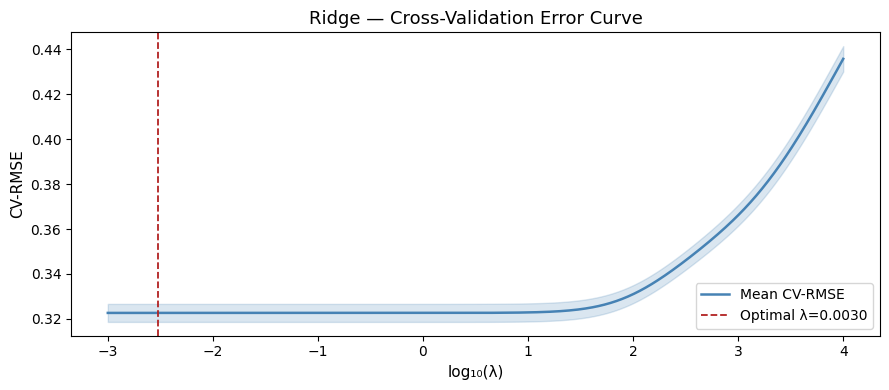

In [17]:
# --- Ridge CV Error Curve ---
ridge_cv_results = pd.DataFrame(ridge_cv.cv_results_).sort_values("param_model__alpha")
ridge_cv_alphas  = ridge_cv_results["param_model__alpha"].astype(float).to_numpy()
mean_cv_rmse_ridge = np.sqrt(-ridge_cv_results["mean_test_score"].to_numpy())
std_cv_rmse_ridge  = ridge_cv_results["std_test_score"].to_numpy() / (2 * mean_cv_rmse_ridge)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.log10(ridge_cv_alphas), mean_cv_rmse_ridge,
        color="steelblue", linewidth=1.8, label="Mean CV-RMSE")
ax.fill_between(
    np.log10(ridge_cv_alphas),
    mean_cv_rmse_ridge - std_cv_rmse_ridge,
    mean_cv_rmse_ridge + std_cv_rmse_ridge,
    alpha=0.2, color="steelblue",
)
ax.axvline(np.log10(best_alpha), color="firebrick", linestyle="--", linewidth=1.3,
           label=f"Optimal λ={best_alpha:.4f}")
ax.set_xlabel("log₁₀(λ)", fontsize=11)
ax.set_ylabel("CV-RMSE", fontsize=11)
ax.set_title("Ridge — Cross-Validation Error Curve", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("plots/section4_PlotRegularization2_ridgeCVCurve.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
# --- Phase 4 Part 4: LASSO Regression ---
# Tune λ via 10-fold CV. Unlike Ridge, LASSO can zero coefficients entirely,
# providing built-in feature selection. Cross-validation is leakage-safe:
# satisfaction PCA and scaling are re-fit inside each fold of the Pipeline.

lasso_alphas = np.logspace(-4, 1, 500)

X_lasso_cv, lasso_pipe = _make_cv_pipe(
    Lasso(max_iter=20000, random_state=42), use_city=True,
)

lasso_cv = GridSearchCV(
    lasso_pipe,
    param_grid={"model__alpha": lasso_alphas},
    cv=10,
    scoring="neg_mean_squared_error",
)
lasso_cv.fit(X_lasso_cv, y_train)

best_lasso_alpha = lasso_cv.best_params_["model__alpha"]
cv_rmse_lasso    = np.sqrt(-lasso_cv.best_score_)

print(f"Optimal λ  : {best_lasso_alpha:.6f}")
print(f"CV-RMSE    : {cv_rmse_lasso:.4f}")

# Refit with optimal λ for the downstream coefficient-table and path-plot cells.
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=20000, random_state=42)
lasso_best.fit(X_train_processed, y_train)

train_pred_lasso = lasso_best.predict(X_train_processed)
test_pred_lasso  = lasso_best.predict(X_test_processed)
train_rmse_lasso = np.sqrt(np.mean((y_train - train_pred_lasso) ** 2))
test_rmse_lasso  = np.sqrt(np.mean((y_test  - test_pred_lasso)  ** 2))

n_nonzero = int(np.sum(lasso_best.coef_ != 0))
print(f"Non-zero coefs : {n_nonzero} out of {X_train_processed.shape[1]}")
print(f"Zeroed out     : {X_train_processed.shape[1] - n_nonzero}")
print(f"Train RMSE     : {train_rmse_lasso:.4f}")
print(f"Test RMSE      : {test_rmse_lasso:.4f}")


Optimal λ  : 0.000100
CV-RMSE    : 0.3227
Non-zero coefs : 23 out of 23
Zeroed out     : 0
Train RMSE     : 0.3224
Test RMSE      : 0.3266


In [19]:
# Coefficient table: OLS vs Ridge vs LASSO
coef_comparison["Full Lasso"] = lasso_best.coef_
coef_comparison["L1 Shrinkage"] = ((coef_comparison["Full OLS"] - coef_comparison["Full Lasso"]).abs()).round(6)
coef_comparison


,Full OLS,Full Ridge,L2 Shrinkage,Full Lasso,L1 Shrinkage
cleanliness_rating,0.036913,0.036913,0.000000,0.036888,0.000025
guest_satisfaction_overall,0.006627,0.006627,0.000000,0.006585,0.000041
person_capacity,0.114951,0.114950,0.000000,0.114187,0.000764
bedrooms,0.075935,0.075935,0.000000,0.076343,0.000408
dist,-0.054671,-0.054671,0.000001,-0.056003,0.001333
metro_dist,-0.016253,-0.016253,0.000001,-0.015168,0.001085
attr_index,0.079369,0.079370,0.000001,0.080582,0.001213
rest_index,0.055498,0.055497,0.000001,0.053355,0.002143
room_type_apt,0.826413,0.826399,0.000013,0.797550,0.028863
room_type_private,0.408385,0.408372,0.000013,0.379437,0.028948


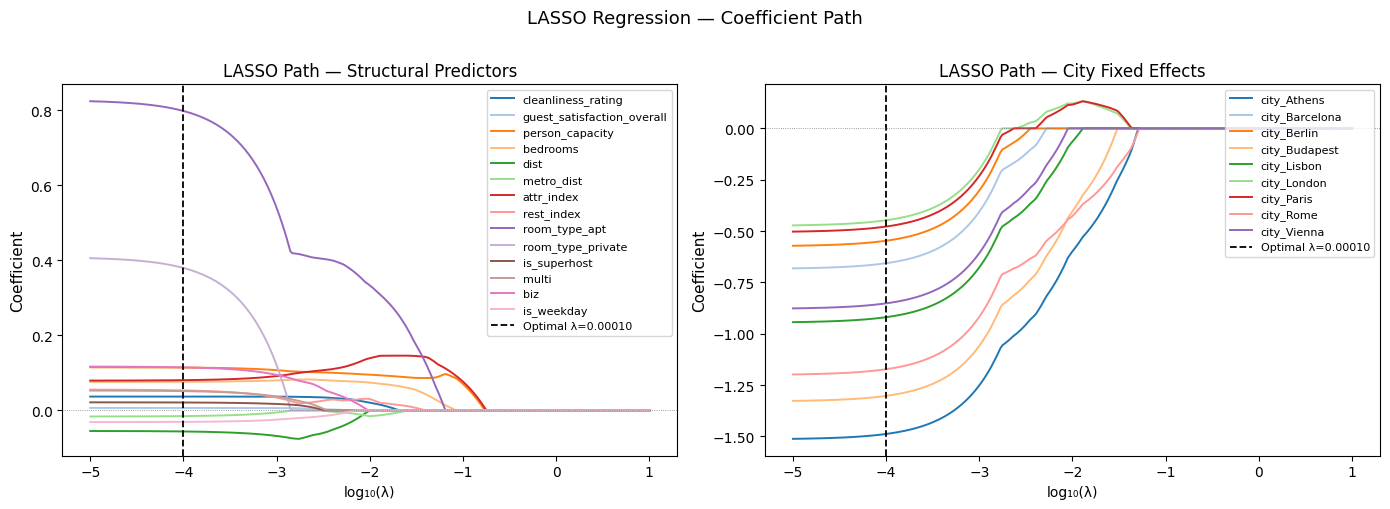

In [20]:
# --- LASSO Coefficient Path ---
# lasso_path has no fit_intercept — center X and y to match Lasso(fit_intercept=True)
_X_path = X_train_processed.to_numpy()
_X_path_mean = _X_path.mean(axis=0)
_y_path_mean = y_train.mean()
alphas_lasso, coefs_lasso, _ = lasso_path(
    _X_path - _X_path_mean, y_train - _y_path_mean,
    alphas=np.logspace(-5, 1, 300),
    max_iter=20000,
)
# coefs_lasso shape: (n_features, n_alphas); alphas decrease left→right

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, group, title in zip(
    axes,
    [structural, city_cols],
    ["Structural Predictors", "City Fixed Effects"],
):
    idxs = [X_train_processed.columns.get_loc(c) for c in group]
    colors = [plt.cm.tab20(i) for i in range(len(group))]
    for (j, col), color in zip(zip(idxs, group), colors):
        ax.plot(np.log10(alphas_lasso), coefs_lasso[j], linewidth=1.4, label=col, color=color)
    ax.axvline(np.log10(best_lasso_alpha), color="black", linestyle="--", linewidth=1.3, label=f"Optimal λ={best_lasso_alpha:.5f}")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
    ax.set_xlabel("log₁₀(λ)", fontsize=10)
    ax.set_ylabel("Coefficient", fontsize=11)
    ax.set_title(f"LASSO Path — {title}", fontsize=12)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("LASSO Regression — Coefficient Path", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/section4_PlotRegularization3_lassoCoefficientPath.png", dpi=300, bbox_inches="tight")
plt.show()


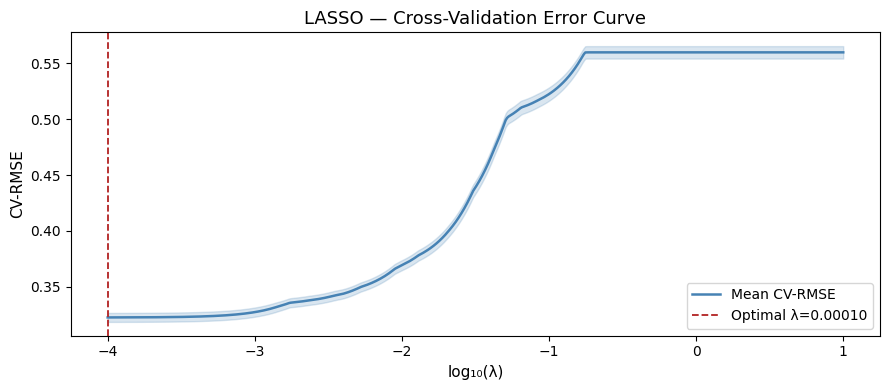

In [21]:
# --- CV Error Curve ---
cv_results = pd.DataFrame(lasso_cv.cv_results_).sort_values("param_model__alpha")
cv_alphas = cv_results["param_model__alpha"].astype(float).to_numpy()
mean_cv_rmse = np.sqrt(-cv_results["mean_test_score"].to_numpy())
std_cv_rmse = cv_results["std_test_score"].to_numpy() / (2 * mean_cv_rmse)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.log10(cv_alphas), mean_cv_rmse,
        color="steelblue", linewidth=1.8, label="Mean CV-RMSE")
ax.fill_between(
    np.log10(cv_alphas),
    mean_cv_rmse - std_cv_rmse,
    mean_cv_rmse + std_cv_rmse,
    alpha=0.2, color="steelblue",
)
ax.axvline(np.log10(best_lasso_alpha), color="firebrick", linestyle="--", linewidth=1.3, label=f"Optimal λ={best_lasso_alpha:.5f}")
ax.set_xlabel("log₁₀(λ)", fontsize=11)
ax.set_ylabel("CV-RMSE", fontsize=11)
ax.set_title("LASSO — Cross-Validation Error Curve", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("plots/section4_PlotRegularization4_lassoCVCurve.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# --- Phase 4 Part 5: Final Model Comparison ---
# Naive OLS re-fit on the training set; City FE OLS already fit in Part 2.
# "Improved OLS" (satisfaction PCA) is not reproduced here since this
# notebook's pipeline scales the raw ratings directly without PCA.

naive_cols = numeric_cols + binary_cols   # 14 features, no city FE

model_naive_tr = sm.OLS(y_train, sm.add_constant(X_train_processed[naive_cols])).fit()

def _ols_preds(model, X_subset):
    return model.predict(sm.add_constant(X_subset, has_constant="add"))

def _test_r2(y_te, preds):
    ss_res = np.sum((y_te - preds) ** 2)
    ss_tot = np.sum((y_te - y_te.mean()) ** 2)
    return 1 - ss_res / ss_tot

def _cv_rmse(estimator, cols, y_tr, cv=10):
    use_city = any(c.startswith("city_") for c in cols)
    X_cv, pipe = _make_cv_pipe(estimator, use_city=use_city)
    scores = cross_val_score(pipe, X_cv, y_tr, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores.mean()))

summary = {}

for label, cols, model in [
    ("Naive OLS",   naive_cols,   model_naive_tr),
    ("City FE OLS", feature_cols, model_city_fe),
]:
    preds = _ols_preds(model, X_test_processed[cols])
    summary[label] = {
        "# Predictors": len(cols),
        "CV-RMSE":    round(_cv_rmse(LinearRegression(), cols, y_train), 4),
        "Train RMSE": round(float(np.sqrt(np.mean((y_train - _ols_preds(model, X_train_processed[cols])) ** 2))), 4),
        "Test RMSE":  round(float(np.sqrt(np.mean((y_test  - preds) ** 2))), 4),
        "Test R²":    round(float(_test_r2(y_test, preds)), 4),
    }

for label, model, cv_estimator in [
    ("Ridge", ridge_best, Ridge(alpha=best_alpha)),
    ("LASSO", lasso_best, Lasso(alpha=best_lasso_alpha, max_iter=20000, random_state=42)),
]:
    tr_pred = model.predict(X_train_processed)
    te_pred = model.predict(X_test_processed)
    summary[label] = {
        "# Predictors": int(np.sum(model.coef_ != 0)),
        "CV-RMSE":    round(_cv_rmse(cv_estimator, feature_cols, y_train), 4),
        "Train RMSE": round(float(np.sqrt(np.mean((y_train - tr_pred) ** 2))), 4),
        "Test RMSE":  round(float(np.sqrt(np.mean((y_test  - te_pred) ** 2))), 4),
        "Test R²":    round(float(_test_r2(y_test, te_pred)), 4),
    }

summary_df = pd.DataFrame(summary).T
summary_df


,# Predictors,CV-RMSE,Train RMSE,Test RMSE,Test R²
Naive OLS,14.0,0.4735,0.4732,0.4737,0.2908
City FE OLS,23.0,0.3226,0.3224,0.3265,0.6631
Ridge,23.0,0.3226,0.3224,0.3265,0.6631
LASSO,23.0,0.3227,0.3224,0.3266,0.6629


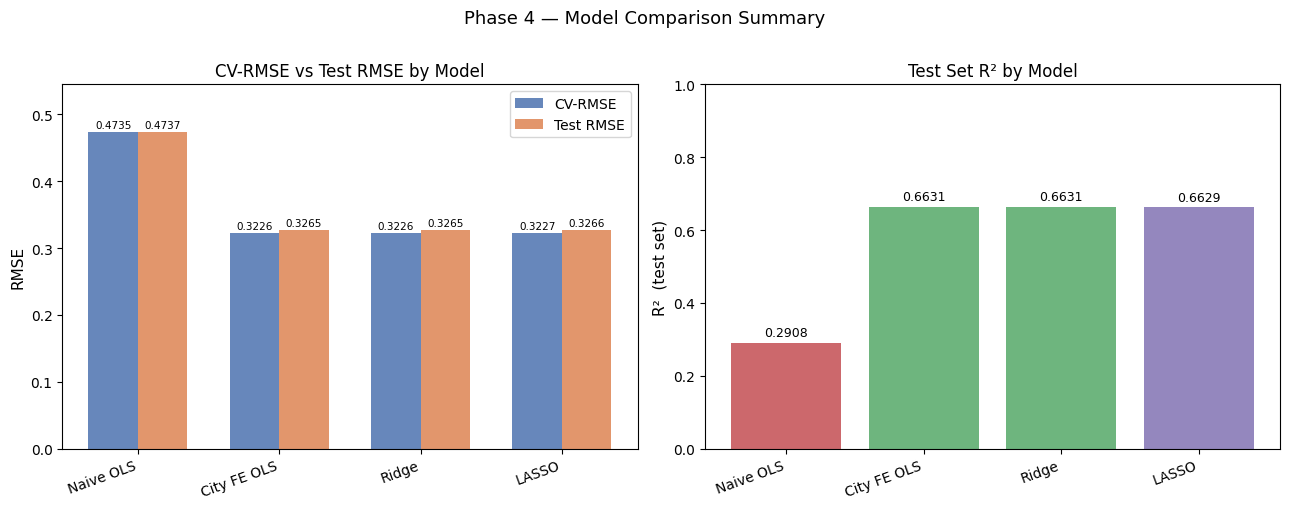

In [23]:
# --- Visualization: Test RMSE and CV-RMSE Comparison ---
model_labels = list(summary_df.index)
x = np.arange(len(model_labels))
width = 0.35

colors_cv   = ["#4c72b0"] * len(model_labels)
colors_test = ["#dd8452"] * len(model_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bar — CV-RMSE vs Test RMSE
ax = axes[0]
bars1 = ax.bar(x - width / 2, summary_df["CV-RMSE"],   width, label="CV-RMSE",   color=colors_cv,   alpha=0.85)
bars2 = ax.bar(x + width / 2, summary_df["Test RMSE"],  width, label="Test RMSE",  color=colors_test, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("RMSE", fontsize=11)
ax.set_title("CV-RMSE vs Test RMSE by Model", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, summary_df[["CV-RMSE", "Test RMSE"]].values.max() * 1.15)
for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7.5)

# Right: Test R²
ax2 = axes[1]
bar_colors = [
    "#55a868" if r == summary_df["Test R²"].max() 
    else "#c44e52" if r == summary_df["Test R²"].min() 
    else "#8172b3" for r in summary_df["Test R²"]
    ]
bars3 = ax2.bar(x, summary_df["Test R²"], color=bar_colors, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(model_labels, rotation=20, ha="right", fontsize=10)
ax2.set_ylabel("R²  (test set)", fontsize=11)
ax2.set_title("Test Set R² by Model", fontsize=12)
ax2.set_ylim(0, 1.0)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Phase 4 — Model Comparison Summary", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/section4_PlotComparison1_linearModels.png", dpi=300, bbox_inches="tight")
plt.show()
